In [28]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [29]:
X = np.load("/kaggle/input/datasets/shubhamrathore850/part-1-train-data-images-npy/Part 1- Train data - images.npy", allow_pickle=True)

print("Total samples:", len(X))

Total samples: 409


In [42]:
import numpy as np
import cv2

X = np.load("/kaggle/input/datasets/shubhamrathore850/part-1-train-data-images-npy/Part 1- Train data - images.npy", allow_pickle=True)

images = []
labels = []

for i in range(len(X)):
    try:
        img = X[i][0]   # image
        ann = X[i][1]   # annotations

        img = np.array(img)

        # -------------------------
        # 🔥 FORCE 3 CHANNELS
        # -------------------------
        if img.ndim == 2:  # grayscale
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        elif img.shape[-1] == 4:  # RGBA → RGB
            img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)

        elif img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)

        # -------------------------
        # RESIZE
        # -------------------------
        img = cv2.resize(img, (224,224))

        # -------------------------
        # FINAL SAFETY CHECK
        # -------------------------
        if img.shape != (224,224,3):
            continue

        # normalize
        img = img.astype("float32") / 255.0

        images.append(img)

        # label
        labels.append(1 if len(ann) > 0 else 0)

    except Exception as e:
        print(f"Skipped {i}: {e}")
        continue

# -------------------------
# SAFE CONVERSION
# -------------------------
X = np.stack(images)   # 🔥 use stack (not array)
y = np.array(labels)

print("Final shape:", X.shape)
print("Labels:", np.unique(y, return_counts=True))

Final shape: (409, 224, 224, 3)
Labels: (array([1]), array([409]))


(np.float64(-0.5), np.float64(649.5), np.float64(332.5), np.float64(-0.5))

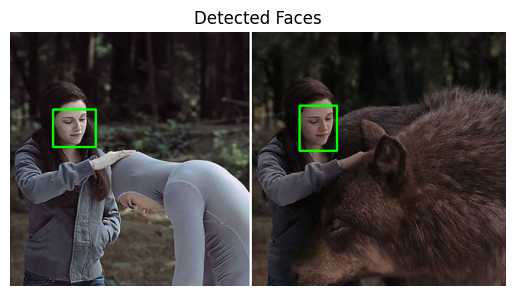

In [32]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

X = np.load("/kaggle/input/datasets/shubhamrathore850/part-1-train-data-images-npy/Part 1- Train data - images.npy", allow_pickle=True)

# pick sample
img = X[0][0].copy()
ann = X[0][1]

h, w = img.shape[:2]

for face in ann:
    p1 = face['points'][0]
    p2 = face['points'][1]

    x1, y1 = int(p1['x'] * w), int(p1['y'] * h)
    x2, y2 = int(p2['x'] * w), int(p2['y'] * h)

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(img)
plt.title("Detected Faces")
plt.axis("off")

(np.float64(-0.5), np.float64(649.5), np.float64(332.5), np.float64(-0.5))

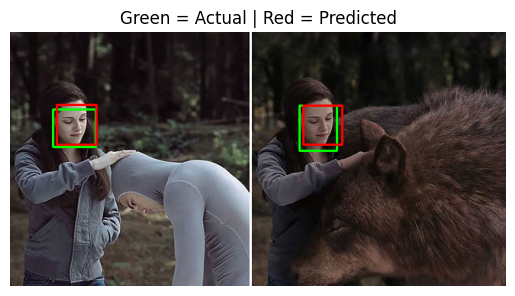

In [33]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# load data
X = np.load("/kaggle/input/datasets/shubhamrathore850/part-1-train-data-images-npy/Part 1- Train data - images.npy", allow_pickle=True)

# load OpenCV model
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# pick sample
img = X[0][0].copy()
ann = X[0][1]

h, w = img.shape[:2]

# -----------------------------
#  DRAW GROUND TRUTH (GREEN)
# -----------------------------
for face in ann:
    p1 = face['points'][0]
    p2 = face['points'][1]

    x1, y1 = int(p1['x'] * w), int(p1['y'] * h)
    x2, y2 = int(p2['x'] * w), int(p2['y'] * h)

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

# -----------------------------
#  DRAW PREDICTION (RED)
# -----------------------------
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x,y,wf,hf) in faces:
    cv2.rectangle(img, (x,y), (x+wf, y+hf), (255,0,0), 2)

# show
plt.imshow(img)
plt.title("Green = Actual | Red = Predicted")
plt.axis("off")

In [36]:
print("Total number of samples:", len(X))
print("Type of dataset:", type(X))
print("Type of one sample:", type(X[0]))

Total number of samples: 409
Type of dataset: <class 'numpy.ndarray'>
Type of one sample: <class 'numpy.ndarray'>


In [37]:
print("Sample structure:")
print(X[0])

Sample structure:
[array([[[42, 37, 34],
         [56, 51, 48],
         [71, 66, 63],
         ...,
         [23, 33, 34],
         [26, 36, 37],
         [28, 38, 39]],

        [[40, 35, 32],
         [51, 46, 43],
         [64, 59, 56],
         ...,
         [27, 36, 35],
         [24, 33, 32],
         [26, 35, 34]],

        [[43, 38, 35],
         [51, 46, 43],
         [61, 56, 53],
         ...,
         [28, 30, 27],
         [33, 35, 32],
         [35, 37, 34]],

        ...,

        [[56, 47, 40],
         [57, 48, 41],
         [61, 52, 45],
         ...,
         [67, 48, 42],
         [55, 35, 28],
         [60, 40, 33]],

        [[53, 44, 37],
         [54, 45, 38],
         [57, 48, 41],
         ...,
         [59, 40, 34],
         [60, 40, 33],
         [54, 34, 27]],

        [[53, 44, 37],
         [54, 45, 38],
         [57, 48, 41],
         ...,
         [59, 40, 34],
         [70, 50, 43],
         [64, 44, 37]]], dtype=uint8)
 list([{'label': ['Face'], 'not

In [38]:
shapes = [X[i][0].shape for i in range(len(X))]

unique_shapes = set(shapes)
print("Unique image shapes:", unique_shapes)

Unique image shapes: {(320, 600, 3), (480, 640, 3), (438, 779, 3), (500, 337, 3), (525, 700, 3), (660, 1160, 3), (255, 600, 3), (422, 759, 3), (312, 750, 4), (346, 614, 3), (1081, 1920, 3), (878, 1920, 3), (2333, 3500, 3), (360, 640, 3), (600, 405, 3), (768, 1024, 3), (1080, 1920, 3), (1080, 1440, 3), (747, 605, 3), (464, 825, 3), (246, 560, 3), (400, 592, 3), (659, 539, 3), (500, 774, 3), (699, 2000, 3), (588, 736, 3), (788, 1500, 3), (631, 992, 3), (627, 1200, 3), (450, 800, 3), (393, 634, 3), (632, 845, 3), (607, 607, 3), (512, 650, 3), (510, 500, 3), (395, 651, 3), (1200, 823, 3), (1024, 3198, 3), (400, 770, 4), (514, 935, 3), (449, 800, 3), (587, 1200, 3), (1000, 2000, 3), (907, 1440, 3), (1810, 2716, 3), (487, 786, 3), (776, 2033, 3), (1584, 2376, 3), (960, 648, 3), (267, 740, 4), (384, 700, 3), (336, 702, 3), (480, 720, 3), (2000, 3000, 3), (570, 570, 3), (578, 540, 3), (2161, 3000, 3), (1280, 2560, 3), (344, 634, 3), (500, 1000, 3), (348, 849, 3), (350, 804, 3), (574, 850, 3), 

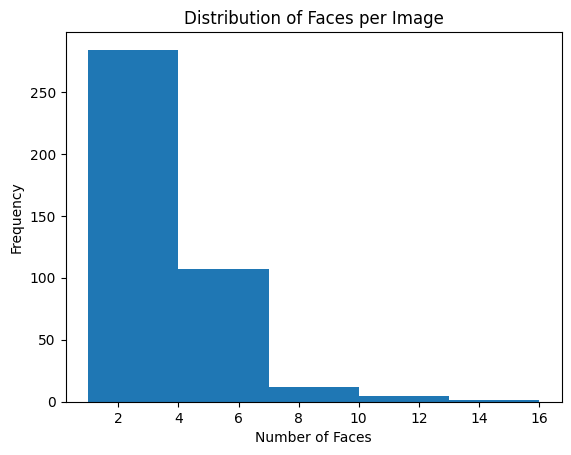

In [39]:
face_counts = [len(X[i][1]) for i in range(len(X))]

import matplotlib.pyplot as plt

plt.hist(face_counts, bins=5)
plt.title("Distribution of Faces per Image")
plt.xlabel("Number of Faces")
plt.ylabel("Frequency")
plt.show()

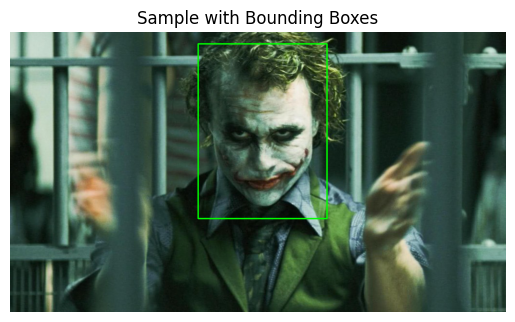

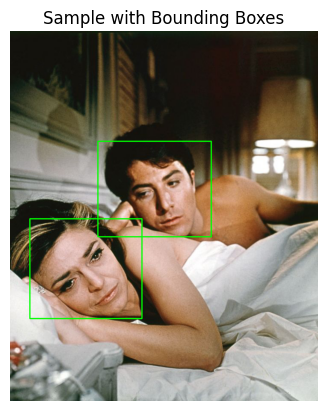

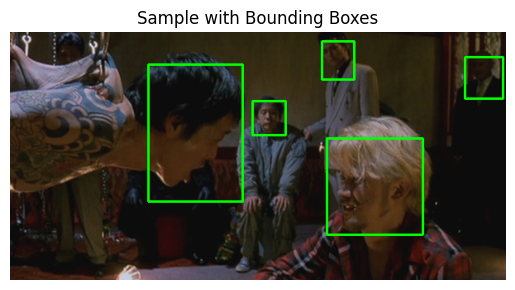

In [40]:
import random

for i in random.sample(range(len(X)), 3):
    img = X[i][0]
    ann = X[i][1]

    img_copy = img.copy()
    h, w = img.shape[:2]

    for face in ann:
        p1 = face['points'][0]
        p2 = face['points'][1]

        x1, y1 = int(p1['x'] * w), int(p1['y'] * h)
        x2, y2 = int(p2['x'] * w), int(p2['y'] * h)

        cv2.rectangle(img_copy, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.imshow(img_copy)
    plt.title("Sample with Bounding Boxes")
    plt.axis("off")
    plt.show()

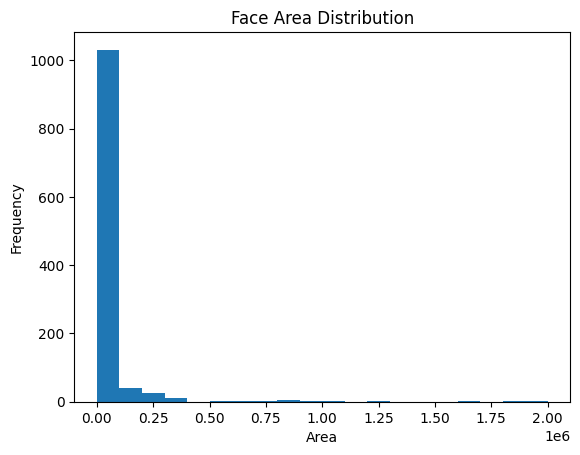

In [41]:
face_areas = []

for i in range(len(X)):
    h, w = X[i][0].shape[:2]
    for face in X[i][1]:
        p1 = face['points'][0]
        p2 = face['points'][1]

        x1, y1 = int(p1['x'] * w), int(p1['y'] * h)
        x2, y2 = int(p2['x'] * w), int(p2['y'] * h)

        area = (x2 - x1) * (y2 - y1)
        face_areas.append(area)

plt.hist(face_areas, bins=20)
plt.title("Face Area Distribution")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()